# Phase 1: Exploratory Data Analysis (EDA)
## Student Graduation Prediction System - Research Project

**Objective**: Comprehensive exploratory data analysis untuk memahami data structure, distributions, relationships, dan potential issues.

**Research Questions**:
- Bagaimana distribusi fitur dalam dataset?
- Adakah outliers atau anomalies?
- Bagaimana relationship antara fitur dan target?
- Adakah multicollinearity atau data quality issues?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## 1. Setup & Import Libraries

In [4]:
df = pd.read_csv('../data/dataset.csv')

print("=" * 70)
print("DATASET OVERVIEW & METADATA")
print("=" * 70)

print(f"\nDataset Dimensions:")
print(f"   Rows (Samples): {df.shape[0]}")
print(f"   Columns (Features): {df.shape[1]}")
print(f"   Data Points: {df.shape[0] * df.shape[1]:,}")

print(f"\nColumn Information:")
for col in df.columns:
    dtype = df[col].dtype
    non_null = df[col].notna().sum()
    null_pct = (df[col].isna().sum() / len(df) * 100)
    print(f"   {col:20s} | Type: {str(dtype):10s} | Non-null: {non_null:3d} ({100-null_pct:5.1f}%)")

print(f"\nFirst 5 Rows:")
display(df.head())

print(f"\nLast 5 Rows:")
display(df.tail())

DATASET OVERVIEW & METADATA

Dataset Dimensions:
   Rows (Samples): 50
   Columns (Features): 6
   Data Points: 300

Column Information:
   nim                  | Type: int64      | Non-null:  50 (100.0%)
   nama                 | Type: object     | Non-null:  50 (100.0%)
   ipk                  | Type: float64    | Non-null:  50 (100.0%)
   absen                | Type: int64      | Non-null:  50 (100.0%)
   kegiatan             | Type: int64      | Non-null:  50 (100.0%)
   lulus_tepat_waktu    | Type: object     | Non-null:  50 (100.0%)

First 5 Rows:


,nim,nama,ipk,absen,kegiatan,lulus_tepat_waktu
0,1,Adi Pratama,3.75,2,5,Ya
1,2,Budi Santoso,3.45,8,3,Tidak
2,3,Citra Dewi,3.90,1,8,Ya
3,4,Doni Hermanto,2.95,15,1,Tidak
4,5,Eka Putri,3.60,5,6,Ya



Last 5 Rows:


,nim,nama,ipk,absen,kegiatan,lulus_tepat_waktu
45,46,Tika Nurahayati,3.00,13,1,Tidak
46,47,Ulfa Azizah,3.55,6,5,Ya
47,48,Visi Kusuma,2.85,16,0,Tidak
48,49,Wira Santoso,3.70,4,7,Ya
49,50,Yana Sartika,3.40,8,3,Tidak


In [5]:
print("=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

# Missing values
print(f"\nMissing Values:")
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_df.to_string(index=False))

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")
if duplicates > 0:
    print("   Duplicate indices:", df[df.duplicated(keep=False)].index.tolist())

# Data type check
print(f"\nData Type Compatibility:")
print(f"   NIM: {df['nim'].dtype} (Expected: object/int)")
print(f"   IPK: {df['ipk'].dtype} (Expected: float64)")
print(f"   Absen: {df['absen'].dtype} (Expected: int64)")
print(f"   Kegiatan: {df['kegiatan'].dtype} (Expected: int64)")
print(f"   Status: {df['lulus_tepat_waktu'].dtype} (Expected: object)")

# Value ranges
print(f"\nValue Range Validation:")
print(f"   IPK range: [{df['ipk'].min():.2f}, {df['ipk'].max():.2f}] (Valid: 0-4.0)")
print(f"   Absen range: [{df['absen'].min()}, {df['absen'].max()}] (Valid: 0-30)")
print(f"   Kegiatan range: [{df['kegiatan'].min()}, {df['kegiatan'].max()}] (Valid: 0-10)")

DATA QUALITY ASSESSMENT

Missing Values:
           Column  Missing_Count  Missing_%
              nim              0        0.0
             nama              0        0.0
              ipk              0        0.0
            absen              0        0.0
         kegiatan              0        0.0
lulus_tepat_waktu              0        0.0

Duplicate Rows: 0

Data Type Compatibility:
   NIM: int64 (Expected: object/int)
   IPK: float64 (Expected: float64)
   Absen: int64 (Expected: int64)
   Kegiatan: int64 (Expected: int64)
   Status: object (Expected: object)

Value Range Validation:
   IPK range: [2.65, 3.95] (Valid: 0-4.0)
   Absen range: [1, 19] (Valid: 0-30)
   Kegiatan range: [0, 9] (Valid: 0-10)


## 3. Missing Values & Data Quality

In [7]:
print("=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

# Missing values
print(f"\n Missing Values:")
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_df.to_string(index=False))

# Duplicates
duplicates = df.duplicated().sum()
print(f"\n Duplicate Rows: {duplicates}")
if duplicates > 0:
    print("   Duplicate indices:", df[df.duplicated(keep=False)].index.tolist())

# Data type check
print(f"\n Data Type Compatibility:")
print(f"   NIM: {df['nim'].dtype} (Expected: object/int)")
print(f"   IPK: {df['ipk'].dtype} (Expected: float64)")
print(f"   Absen: {df['absen'].dtype} (Expected: int64)")
print(f"   Kegiatan: {df['kegiatan'].dtype} (Expected: int64)")
print(f"   Status: {df['lulus_tepat_waktu'].dtype} (Expected: object)")

# Value ranges
print(f"\nValue Range Validation:")
print(f"   IPK range: [{df['ipk'].min():.2f}, {df['ipk'].max():.2f}] (Valid: 0-4.0)")
print(f"   Absen range: [{df['absen'].min()}, {df['absen'].max()}] (Valid: 0-30)")
print(f"   Kegiatan range: [{df['kegiatan'].min()}, {df['kegiatan'].max()}] (Valid: 0-10)")

DATA QUALITY ASSESSMENT

 Missing Values:
           Column  Missing_Count  Missing_%
              nim              0        0.0
             nama              0        0.0
              ipk              0        0.0
            absen              0        0.0
         kegiatan              0        0.0
lulus_tepat_waktu              0        0.0

 Duplicate Rows: 0

 Data Type Compatibility:
   NIM: int64 (Expected: object/int)
   IPK: float64 (Expected: float64)
   Absen: int64 (Expected: int64)
   Kegiatan: int64 (Expected: int64)
   Status: object (Expected: object)

Value Range Validation:
   IPK range: [2.65, 3.95] (Valid: 0-4.0)
   Absen range: [1, 19] (Valid: 0-30)
   Kegiatan range: [0, 9] (Valid: 0-10)


## 4. Descriptive Statistics & Univariate Analysis

In [8]:
print("=" * 70)
print("DESCRIPTIVE STATISTICS (NUMERICAL FEATURES)")
print("=" * 70)

# Detailed statistics
features = ['ipk', 'absen', 'kegiatan']
stats_df = df[features].describe().round(4)
print("\nSummary Statistics:")
print(stats_df)

print("\nAdditional Statistics:")
additional_stats = pd.DataFrame({
    'Feature': features,
    'Mean': [df[f].mean() for f in features],
    'Std Dev': [df[f].std() for f in features],
    'CV (%)': [(df[f].std() / df[f].mean() * 100) for f in features],
    'Skewness': [stats.skew(df[f]) for f in features],
    'Kurtosis': [stats.kurtosis(df[f]) for f in features],
    'Normal?': [stats.normaltest(df[f])[1] > 0.05 for f in features]
})
print(additional_stats.to_string(index=False))

print("\nTarget Variable Distribution:")
target_dist = df['lulus_tepat_waktu'].value_counts()
target_pct = df['lulus_tepat_waktu'].value_counts(normalize=True) * 100
for val in sorted(df['lulus_tepat_waktu'].unique()):
    count = target_dist[val]
    pct = target_pct[val]
    bar = "" * int(pct / 2)
    print(f"   {val:10s}: {count:3d} ({pct:5.1f}%) {bar}")

# Outlier detection using IQR
print("\nOutlier Detection (IQR Method):")
for feature in features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    print(f"   {feature:10s}: {len(outliers):2d} outliers (bounds: [{lower_bound:.2f}, {upper_bound:.2f}])")

DESCRIPTIVE STATISTICS (NUMERICAL FEATURES)

Summary Statistics:
           ipk    absen  kegiatan
count  50.0000  50.0000   50.0000
mean    3.3780   8.3600    3.9800
std     0.3907   5.2867    2.8175
min     2.6500   1.0000    0.0000
25%     3.0500   4.0000    1.2500
50%     3.4750   7.5000    3.5000
75%     3.7375  12.7500    6.0000
max     3.9500  19.0000    9.0000

Additional Statistics:
 Feature  Mean  Std Dev    CV (%)  Skewness  Kurtosis  Normal?
     ipk 3.378 0.390729 11.566883 -0.300314 -1.252079    False
   absen 8.360 5.286718 63.238254  0.351669 -1.094233    False
kegiatan 3.980 2.817511 70.791730  0.169907 -1.316381    False

Target Variable Distribution:
   Tidak     :  25 ( 50.0%) 
   Ya        :  25 ( 50.0%) 

Outlier Detection (IQR Method):
   ipk       :  0 outliers (bounds: [2.02, 4.77])
   absen     :  0 outliers (bounds: [-9.12, 25.88])
   kegiatan  :  0 outliers (bounds: [-5.88, 13.12])


## 5. Bivariate Analysis & Correlation

In [9]:
print("=" * 70)
print("CORRELATION & RELATIONSHIP ANALYSIS")
print("=" * 70)

# Correlation matrix
print("\nPearson Correlation Matrix:")
corr_matrix = df[features].corr().round(4)
print(corr_matrix)

# Check multicollinearity (VIF akan dihitung di feature engineering)
print("\nMulticollinearity Check (Correlation):")
for i, feat1 in enumerate(features):
    for feat2 in features[i+1:]:
        corr = corr_matrix.loc[feat1, feat2]
        print(f"   {feat1} vs {feat2}: {corr:.4f} {'[WARNING] HIGH' if abs(corr) > 0.7 else '[OK]'}")

# Stratified analysis
print("\nFeature Statistics by Target Variable:")
for target_val in sorted(df['lulus_tepat_waktu'].unique()):
    subset = df[df['lulus_tepat_waktu'] == target_val][features]
    print(f"\n   Status: {target_val}")
    print(f"   Sample Size: {len(subset)}")
    for feat in features:
        mean_val = subset[feat].mean()
        std_val = subset[feat].std()
        print(f"      {feat:10s}: μ={mean_val:.4f}, σ={std_val:.4f}")

# T-tests untuk masing-masing feature
print("\nStatistical Significance Tests (T-test):")
lulus_data = df[df['lulus_tepat_waktu'] == 'Ya'][features]
tidak_lulus_data = df[df['lulus_tepat_waktu'] == 'Tidak'][features]

for feat in features:
    t_stat, p_val = stats.ttest_ind(lulus_data[feat], tidak_lulus_data[feat])
    significant = "[YES] Significant" if p_val < 0.05 else "[NO] Not Significant"
    print(f"   {feat:10s}: t={t_stat:7.4f}, p={p_val:.6f} → {significant}")

CORRELATION & RELATIONSHIP ANALYSIS

Pearson Correlation Matrix:
             ipk   absen  kegiatan
ipk       1.0000 -0.9939    0.9571
absen    -0.9939  1.0000   -0.9490
kegiatan  0.9571 -0.9490    1.0000

Multicollinearity Check (Correlation):
   ipk vs absen: -0.9939 [WARNING] HIGH
   ipk vs kegiatan: 0.9571 [WARNING] HIGH
   absen vs kegiatan: -0.9490 [WARNING] HIGH

Feature Statistics by Target Variable:

   Status: Tidak
   Sample Size: 25
      ipk       : μ=3.0380, σ=0.2315
      absen     : μ=12.9200, σ=3.2265
      kegiatan  : μ=1.4800, σ=1.0456

   Status: Ya
   Sample Size: 25
      ipk       : μ=3.7180, σ=0.1314
      absen     : μ=3.8000, σ=1.8257
      kegiatan  : μ=6.4800, σ=1.4468

Statistical Significance Tests (T-test):
   ipk       : t=12.7720, p=0.000000 → [YES] Significant
   absen     : t=-12.3004, p=0.000000 → [YES] Significant
   kegiatan  : t=14.0046, p=0.000000 → [YES] Significant


VIOLIN PLOTS - DETAILED DISTRIBUTION ANALYSIS


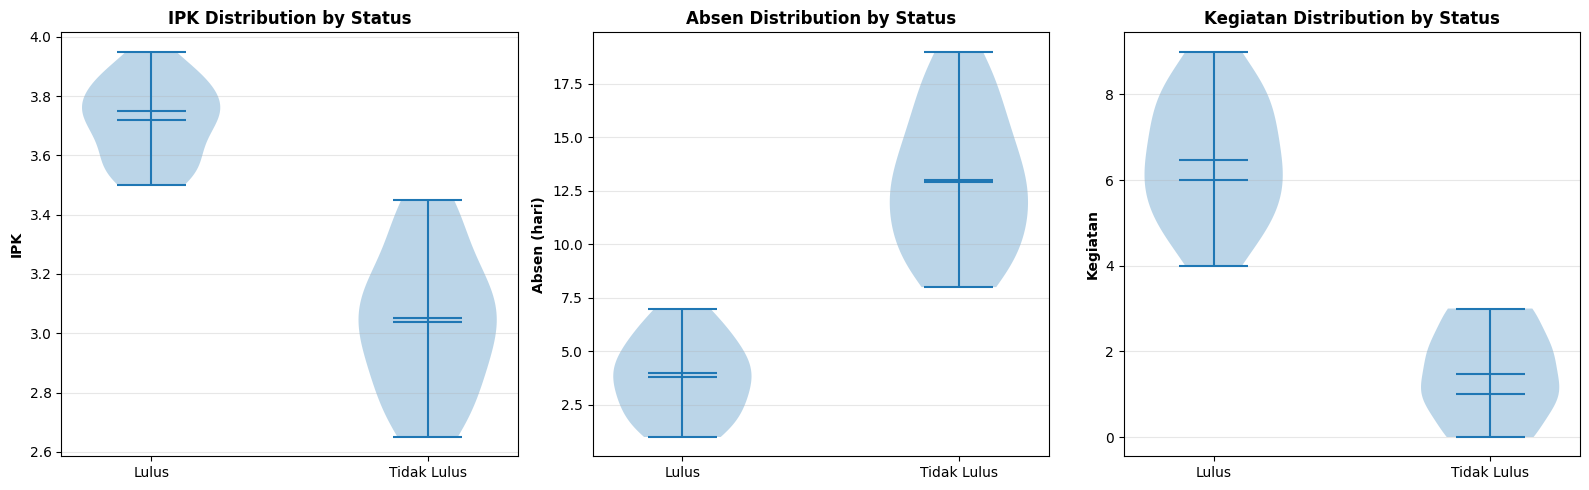


✓ Violin plot visualizations displayed


In [10]:
# Violin plots untuk distribusi yang lebih detail
print("=" * 70)
print("VIOLIN PLOTS - DETAILED DISTRIBUTION ANALYSIS")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# IPK Violin Plot
parts1 = axes[0].violinplot([df[df['lulus_tepat_waktu'] == 'Ya']['ipk'].values,
                             df[df['lulus_tepat_waktu'] == 'Tidak']['ipk'].values],
                            positions=[1, 2], showmeans=True, showmedians=True)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['Lulus', 'Tidak Lulus'])
axes[0].set_ylabel('IPK', fontweight='bold')
axes[0].set_title('IPK Distribution by Status', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Absen Violin Plot
parts2 = axes[1].violinplot([df[df['lulus_tepat_waktu'] == 'Ya']['absen'].values,
                             df[df['lulus_tepat_waktu'] == 'Tidak']['absen'].values],
                            positions=[1, 2], showmeans=True, showmedians=True)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Lulus', 'Tidak Lulus'])
axes[1].set_ylabel('Absen (hari)', fontweight='bold')
axes[1].set_title('Absen Distribution by Status', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Kegiatan Violin Plot
parts3 = axes[2].violinplot([df[df['lulus_tepat_waktu'] == 'Ya']['kegiatan'].values,
                             df[df['lulus_tepat_waktu'] == 'Tidak']['kegiatan'].values],
                            positions=[1, 2], showmeans=True, showmedians=True)
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Lulus', 'Tidak Lulus'])
axes[2].set_ylabel('Kegiatan', fontweight='bold')
axes[2].set_title('Kegiatan Distribution by Status', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Violin plot visualizations displayed")

CORRELATION HEATMAP


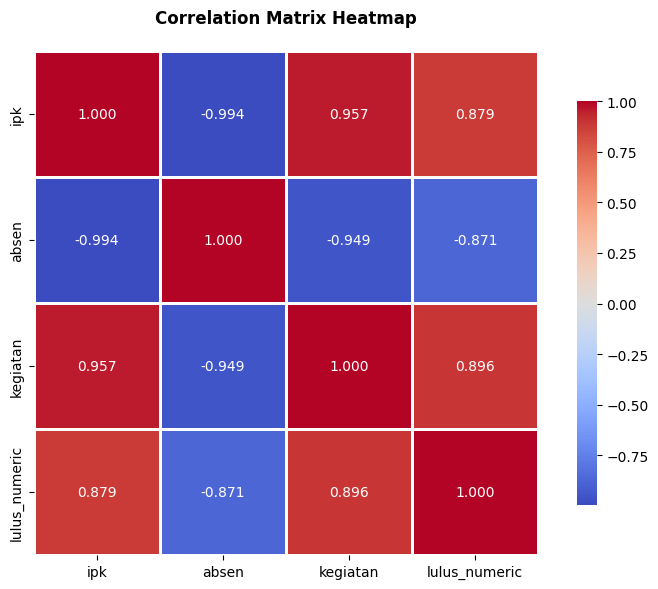


✓ Heatmap displayed

Interpretasi:
  Nilai mendekati 1: Korelasi positif kuat
  Nilai mendekati -1: Korelasi negatif kuat
  Nilai mendekati 0: Tidak ada korelasi


In [11]:
# Correlation Heatmap
print("=" * 70)
print("CORRELATION HEATMAP")
print("=" * 70)

# Encode target variable untuk correlation
df_corr = df[features].copy()
df_corr['lulus_numeric'] = (df['lulus_tepat_waktu'] == 'Ya').astype(int)

# Create heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix Heatmap', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✓ Heatmap displayed")
print("\nInterpretasi:")
print("  Nilai mendekati 1: Korelasi positif kuat")
print("  Nilai mendekati -1: Korelasi negatif kuat")
print("  Nilai mendekati 0: Tidak ada korelasi")

SCATTER PLOTS - FEATURE RELATIONSHIPS


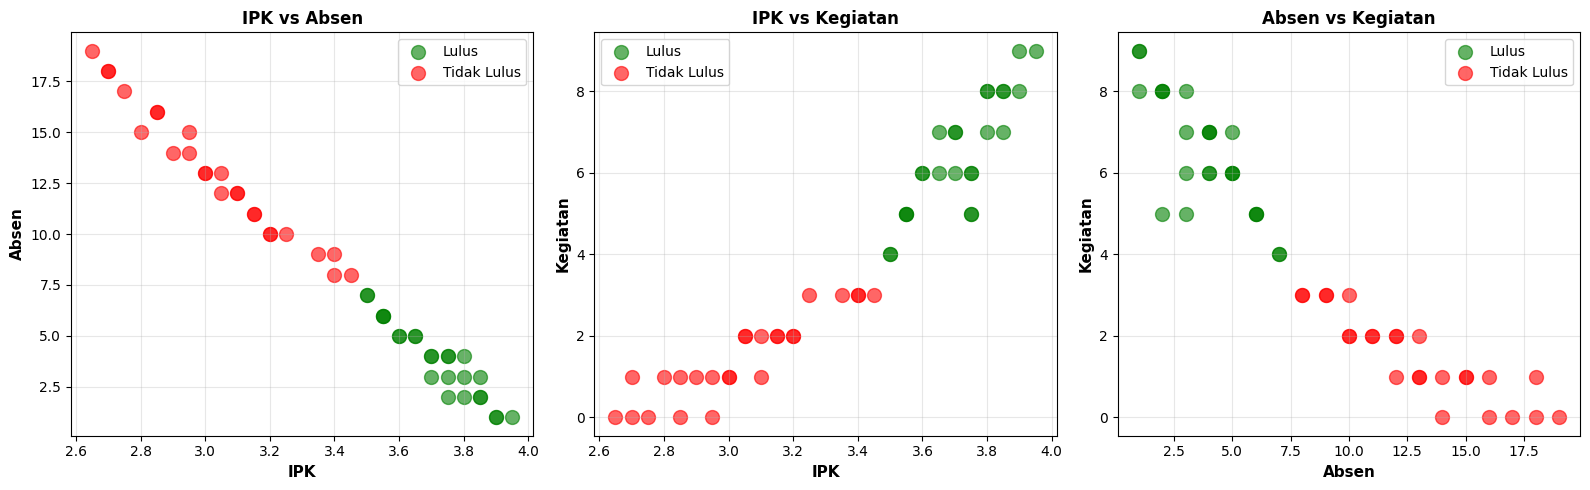


✓ Scatter plot visualizations displayed


In [12]:
# Scatter plots untuk melihat relationships
print("=" * 70)
print("SCATTER PLOTS - FEATURE RELATIONSHIPS")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# IPK vs Absen
lulus = df[df['lulus_tepat_waktu'] == 'Ya']
tidak_lulus = df[df['lulus_tepat_waktu'] == 'Tidak']

axes[0].scatter(lulus['ipk'], lulus['absen'], label='Lulus', color='green', alpha=0.6, s=100)
axes[0].scatter(tidak_lulus['ipk'], tidak_lulus['absen'], label='Tidak Lulus', color='red', alpha=0.6, s=100)
axes[0].set_xlabel('IPK', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Absen', fontsize=11, fontweight='bold')
axes[0].set_title('IPK vs Absen', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# IPK vs Kegiatan
axes[1].scatter(lulus['ipk'], lulus['kegiatan'], label='Lulus', color='green', alpha=0.6, s=100)
axes[1].scatter(tidak_lulus['ipk'], tidak_lulus['kegiatan'], label='Tidak Lulus', color='red', alpha=0.6, s=100)
axes[1].set_xlabel('IPK', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Kegiatan', fontsize=11, fontweight='bold')
axes[1].set_title('IPK vs Kegiatan', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Absen vs Kegiatan
axes[2].scatter(lulus['absen'], lulus['kegiatan'], label='Lulus', color='green', alpha=0.6, s=100)
axes[2].scatter(tidak_lulus['absen'], tidak_lulus['kegiatan'], label='Tidak Lulus', color='red', alpha=0.6, s=100)
axes[2].set_xlabel('Absen', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Kegiatan', fontsize=11, fontweight='bold')
axes[2].set_title('Absen vs Kegiatan', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Scatter plot visualizations displayed")

BOX PLOTS - OUTLIERS & DISTRIBUTION ANALYSIS


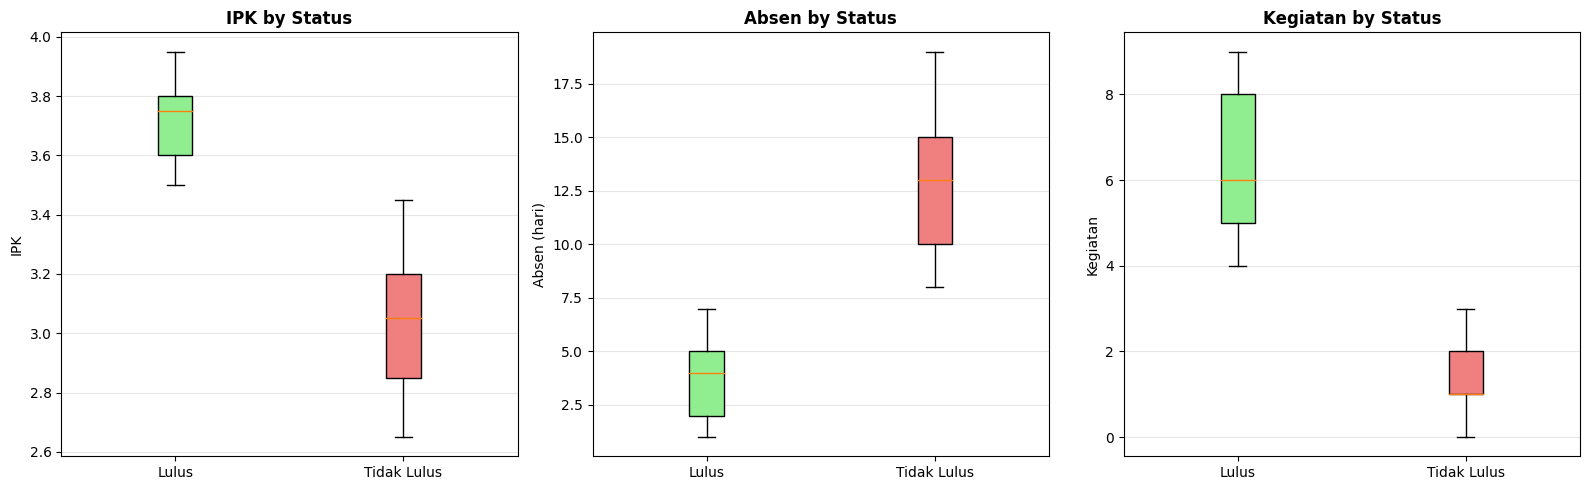


✓ Box plot visualizations displayed


In [13]:
# Box plots untuk melihat outliers dan distribusi per grup
print("=" * 70)
print("BOX PLOTS - OUTLIERS & DISTRIBUTION ANALYSIS")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# IPK Box Plot
bp1 = axes[0].boxplot([df[df['lulus_tepat_waktu'] == 'Ya']['ipk'],
                        df[df['lulus_tepat_waktu'] == 'Tidak']['ipk']],
                       labels=['Lulus', 'Tidak Lulus'],
                       patch_artist=True)
for patch, color in zip(bp1['boxes'], ['lightgreen', 'lightcoral']):
    patch.set_facecolor(color)
axes[0].set_title('IPK by Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('IPK')
axes[0].grid(axis='y', alpha=0.3)

# Absen Box Plot
bp2 = axes[1].boxplot([df[df['lulus_tepat_waktu'] == 'Ya']['absen'],
                        df[df['lulus_tepat_waktu'] == 'Tidak']['absen']],
                       labels=['Lulus', 'Tidak Lulus'],
                       patch_artist=True)
for patch, color in zip(bp2['boxes'], ['lightgreen', 'lightcoral']):
    patch.set_facecolor(color)
axes[1].set_title('Absen by Status', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Absen (hari)')
axes[1].grid(axis='y', alpha=0.3)

# Kegiatan Box Plot
bp3 = axes[2].boxplot([df[df['lulus_tepat_waktu'] == 'Ya']['kegiatan'],
                        df[df['lulus_tepat_waktu'] == 'Tidak']['kegiatan']],
                       labels=['Lulus', 'Tidak Lulus'],
                       patch_artist=True)
for patch, color in zip(bp3['boxes'], ['lightgreen', 'lightcoral']):
    patch.set_facecolor(color)
axes[2].set_title('Kegiatan by Status', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Kegiatan')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Box plot visualizations displayed")

FEATURE DISTRIBUTIONS


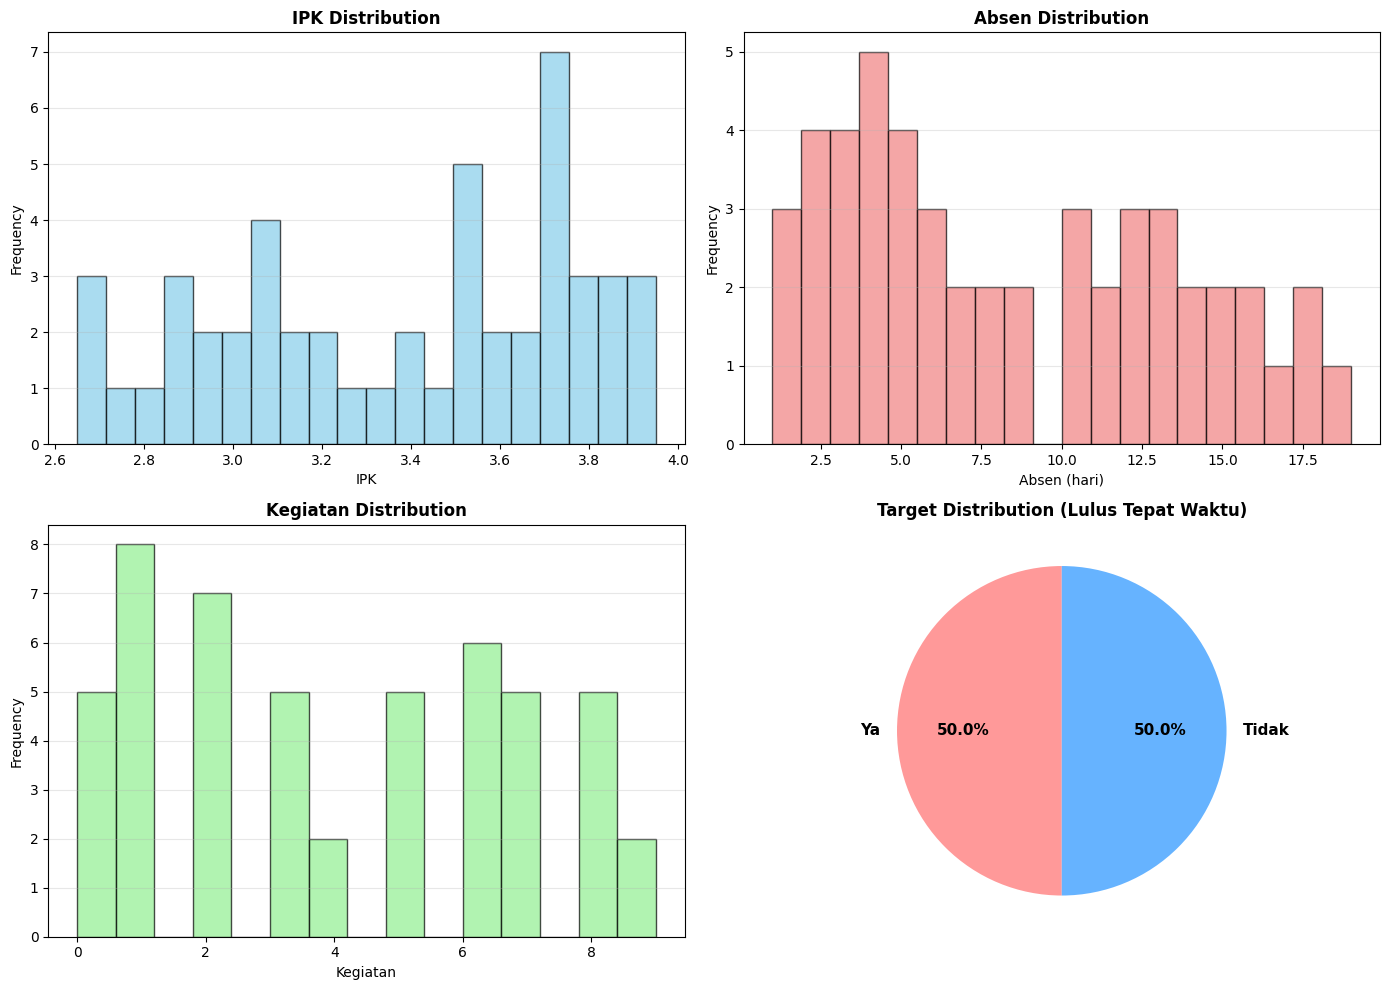


✓ Distribution visualizations displayed


In [14]:
# Distribution plots untuk features numerik
print("=" * 70)
print("FEATURE DISTRIBUTIONS")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# IPK Distribution
axes[0, 0].hist(df['ipk'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('IPK Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('IPK')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(axis='y', alpha=0.3)

# Absen Distribution
axes[0, 1].hist(df['absen'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Absen Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Absen (hari)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(axis='y', alpha=0.3)

# Kegiatan Distribution
axes[1, 0].hist(df['kegiatan'], bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Kegiatan Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Kegiatan')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(axis='y', alpha=0.3)

# Target Distribution
target_counts = df['lulus_tepat_waktu'].value_counts()
colors = ['#ff9999', '#66b3ff']
axes[1, 1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', 
               colors=colors, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
axes[1, 1].set_title('Target Distribution (Lulus Tepat Waktu)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Distribution visualizations displayed")